<a href="https://colab.research.google.com/github/TenofJiwon/DerivativeSecurities/blob/main/GARCH_Modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

              005930    000660    373220     207940    005380   KS200    NVDA  \
Date                                                                            
2021-01-04   83000.0  126000.0       NaN   819298.0  207500.0  399.88   13.11   
2021-01-05   83900.0  130500.0       NaN   822263.0  209500.0  406.03   13.40   
2021-01-06   82200.0  131000.0       NaN   807438.0  203000.0  402.08   12.61   
2021-01-07   82900.0  134500.0       NaN   809415.0  206000.0  410.81   13.34   
2021-01-08   88800.0  138000.0       NaN   827204.0  246000.0  430.22   13.28   
...              ...       ...       ...        ...       ...     ...     ...   
2025-11-10  100600.0  606000.0  465500.0  1221000.0  270500.0  575.31  199.05   
2025-11-11  103500.0  619000.0  473000.0  1221000.0  269000.0  581.41  193.16   
2025-11-12  103100.0  617000.0  475500.0  1221000.0  275500.0  586.73  193.80   
2025-11-13  102800.0  612000.0  484500.0  1221000.0  278500.0  588.65  186.86   
2025-11-14   97200.0  560000

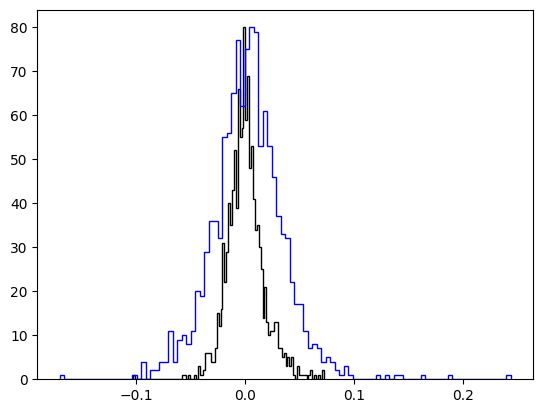

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

data=pd.read_excel('/content/stock_data.xlsx')
data=data.set_index('Date')
start='20210101'
end='20251114'
data=data.loc[start:end]

print(data)

price1=data['005930'].dropna()
price2=data['NVDA'].dropna()

ret1 = price1.pct_change()
ret2 = price2.pct_change()

print("")
print("[Stock1(black)]")
print('mean: %0.6f' % (ret1.mean()))
print('std: %0.6f' % (ret1.std()))
print("")

print("[Stock2(blue)]") # 여기는 히스토그램에서 파란색으로 표시될 예정입니다.
print('mean: %0.6f' % (ret2.mean()))
print('std: %0.6f' % (ret2.std()))

# print.hist(...)는 오류입니다. matplotlib.pyplot (plt)의 함수를 사용해야 합니다.
# 또한, 두 번째 히스토그램의 색상을 'blue'로 수정합니다.
plt.hist(ret1, bins=100, histtype='step', color='black', label='Stock1 (005930)')
plt.hist(ret2, bins=100, histtype='step', color='blue', label='Stock2 (NVDA)') # 색상 'blue'로 수정

plt.show()


In [ ]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 10.7 MB/s eta 0:00:00


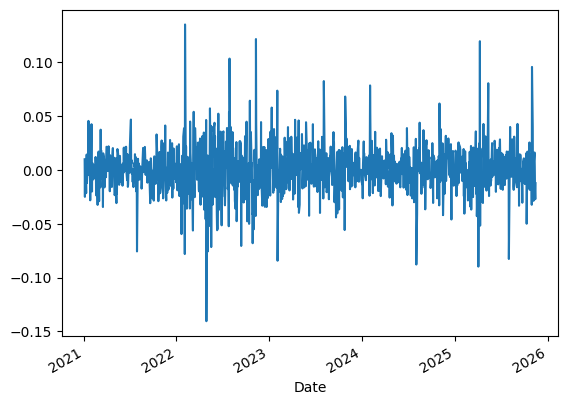

Iteration:      1,   Func. Count:      6,   Neg. LLF: 1.2866064737799242e+16
Iteration:      2,   Func. Count:     18,   Neg. LLF: 7449494.992122885
Optimization terminated successfully    (Exit mode 0)
            Current function value: -2983.7044433619476
            Iterations: 2
            Function evaluations: 28
            Gradient evaluations: 2
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                   AMZN   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                2983.70
Distribution:                  Normal   AIC:                          -5959.41
Method:            Maximum Likelihood   BIC:                          -5938.97
                                        No. Observations:                 1223
Date:                Mon, Nov 17 2025   Df Residuals:                     1222
Time:     

/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0004958. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


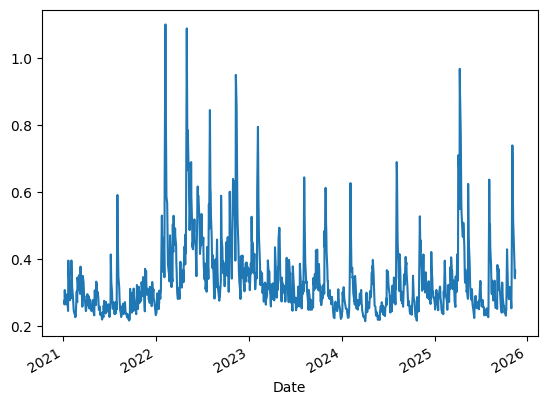

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model

# arch 모듈 설치는 이미 완료되었다고 가정합니다.

data = pd.read_excel('/content/stock_data.xlsx')
data = data.set_index('Date')
# 날짜 인덱싱을 위해 인덱스 타입을 datetime으로 변환하는 코드를 추가합니다.
data.index = pd.to_datetime(data.index)
start = '20210101'
end = '20251114'
data = data.loc[start:end]

price1 = data['AMZN'].dropna()
# [수정 1] pct_change()로 인해 발생하는 NaN 값을 제거합니다. (에러 해결 핵심)
returns = price1.pct_change().dropna()
returns.plot()
plt.show()

model = arch_model(returns, vol='Garch', p=1, o=0, q=1, dist='Normal')
# fit 시 로그 출력을 줄이기 위해 disp='off'를 추가합니다.
results = model.fit()
print(results.summary())

omega = results.params['omega']
alpha = results.params['alpha[1]']
beta = results.params['beta[1]']
VL = omega / (1 - alpha - beta)
annual_VL_std = np.sqrt(VL) * np.sqrt(252)
# conditional_volatility는 Series 형태이므로 iloc[-1]로 마지막 값을 선택합니다.
annual_garch_vol = results.conditional_volatility.iloc[-1] * np.sqrt(252)
# [수정 2] ret1 -> returns로 변수명 수정
annual_std_vol = returns.std() * np.sqrt(252)

print('Annualized VL(std):%3f' % (annual_VL_std))
print('Annualized garch vol(std):%3f' % (annual_garch_vol))
print('Annualized std vol(std):%3f' % (annual_std_vol))

plt.close()
annual_garch_vol = results.conditional_volatility * np.sqrt(252)
annual_garch_vol.plot()
plt.show()